In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from community import community_louvain
from networkx.algorithms import bipartite
from networkx.drawing.layout import bipartite_layout
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull
import numpy as np
import matplotlib.patches as mpatches
from collections import Counter
from upsetplot import UpSet, from_indicators

In [2]:
# load genes
RNAAgeCalcP = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/00geneRNAAgeCalc-08202025.csv'
EpigeneticsP = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/01EpigeneticCLocks_CpG_GeneAnnotations-08202025.csv'
NewTrainningP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv"
GSEP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/gse_columns.csv"
UTHealthP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/uthealth_columns.csv"
VABBP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/vabb_columns.csv"
ensembl2symbolP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/03references/03epiclocks/ensembl_to_gene.csv"
# Load the CSV files
RNAAgeCalc = pd.read_csv(RNAAgeCalcP)
Epigenetics = pd.read_csv(EpigeneticsP)
NewTraining = pd.read_csv(NewTrainningP)
GSE = pd.read_csv(GSEP)
UTHealth = pd.read_csv(UTHealthP)
VABB = pd.read_csv(VABBP)
symbol_to_ensembl = pd.read_csv(ensembl2symbolP)  # Replace with your file path

In [3]:
# -------------------------
# Mapping KPANN symbols to Ensembl
# -------------------------
# Create a mapping dictionary
symbol_dict = dict(zip(symbol_to_ensembl['gene'], symbol_to_ensembl['ensemblID']))

# Example datasets
datasets = {
    'GSE': 'Genes',
    'UTHealth': 'Genes',
    'VABB': 'Genes'
}
# Add Ensembl Gene ID to each dataset
for ds_name, gene_col in datasets.items():
    df = globals()[ds_name]  # Get DataFrame by name
    # Ensure column exists
    if gene_col in df.columns:
        df['EnsemblID'] = df[gene_col].map(lambda x: symbol_dict.get(x) if pd.notna(x) else None)

# Extract unique gene symbols
GSE_genes = set(GSE['EnsemblID'].dropna())
UTHealth_genes = set(UTHealth['EnsemblID'].dropna())
VABB_genes = set(VABB['EnsemblID'].dropna())
# Find the intersection of all three sets
common_genes = GSE_genes & UTHealth_genes & VABB_genes

# Plot Venn diagram
#plt.figure(figsize=(8, 8))
#venn3([GSE_genes, UTHealth_genes, VABB_genes],
#      set_labels=('GSE', 'UTHealth', 'VABB'))

#plt.title("Venn Diagram of Gene Symbols")
#plt.show()

# common_genes is a set of Ensembl IDs
df_common = pd.DataFrame({
    'Ensembl': list(common_genes),
    'Clock': 'KPANN',
    'Type': 'Transcriptome'
})

df_common.reset_index(drop=True, inplace=True)
df_common.shape

(3362, 3)

In [4]:
# -------------------------
# Filter only brain tissues in RNASeq signatures
# -------------------------
# Subsetting to brain only
RNAAgeCalc = RNAAgeCalc[RNAAgeCalc["Tissue"].str.contains("brain")]
# Create new DataFrame
df_brain_nodes = pd.DataFrame({
    'Ensembl': RNAAgeCalc['Ensembl'],
    'Clock': RNAAgeCalc['Signature'],
    'Type': 'Transcriptome'
})
# Original list of clocks
unique_clocks = ['DESeq2', 'Pearson', 'Dev', 'deMagalhaes', 'GenAge', 'GTExAge', 'Peters', 'all']
# Update names: replace 'all' with 'All' and prepend 'RNAAgeCalc:' to all
updated_clocks = [f"RNAAgeCalc:{c.capitalize()}" if c.lower() == 'all' else f"RNAAgeCalc:{c}" for c in unique_clocks]
df_brain_nodes.reset_index(drop=True, inplace=True)
# Create mapping from old Clock names to updated Clock names
clock_map = dict(zip(unique_clocks, updated_clocks))
# Update Clock column in the DataFrame
df_brain_nodes['Clock'] = df_brain_nodes['Clock'].map(clock_map)
df_brain_nodes.head()

,Ensembl,Clock,Type
0,ENSG00000198417,RNAAgeCalc:DESeq2,Transcriptome
1,ENSG00000187922,RNAAgeCalc:DESeq2,Transcriptome
2,ENSG00000205358,RNAAgeCalc:DESeq2,Transcriptome
3,ENSG00000125144,RNAAgeCalc:DESeq2,Transcriptome
4,ENSG00000176978,RNAAgeCalc:DESeq2,Transcriptome


In [5]:
# Assume your DataFrame is called NewTraining
NewTraining['Clock'] = 'ThisStudy'
NewTraining['Type'] = 'Transcriptome'
# Optional: reorder columns if you want
NewTraining = NewTraining[['Unnamed: 0', 'coef', 'Clock', 'Type']]
# Drop the 'coef' column
NewTraining = NewTraining.drop(columns=['coef'])
# Rename column
NewTraining = NewTraining.rename(columns={'Unnamed: 0': 'Ensembl'})
NewTraining.head()

,Ensembl,Clock,Type
0,ENSG00000006210,ThisStudy,Transcriptome
1,ENSG00000007516,ThisStudy,Transcriptome
2,ENSG00000008118,ThisStudy,Transcriptome
3,ENSG00000008283,ThisStudy,Transcriptome
4,ENSG00000010818,ThisStudy,Transcriptome


In [6]:
# Assume your DataFrame is called Epigenetics
# Keep only the first Ensembl ID if multiple are separated by ';'
Epigenetics['Ensembl'] = Epigenetics['EnsemblID'].str.split(';').str[0]
# Create the new DataFrame
df_epigenetic_nodes = pd.DataFrame({
    'Ensembl': Epigenetics['Ensembl'],
    'Clock': Epigenetics['Clock'],
    'Type': 'Epigenetic'
})
# Drop rows where Ensembl is missing
df_epigenetic_nodes = df_epigenetic_nodes.dropna(subset=['Ensembl']).reset_index(drop=True)
# Remove epiTOc2 from the clock list
df_epigenetic_nodes = df_epigenetic_nodes[df_epigenetic_nodes["Clock"] != "EpiTOC1"]
# Reset index if needed
df_epigenetic_nodes = df_epigenetic_nodes.reset_index(drop=True)
# Check
df_epigenetic_nodes.head()

,Ensembl,Clock,Type
0,ENSG00000134202,DNAmClockCortical,Epigenetic
1,ENSG00000143156,DNAmClockCortical,Epigenetic
2,ENSG00000174606,DNAmClockCortical,Epigenetic
3,ENSG00000117308,DNAmClockCortical,Epigenetic
4,ENSG00000168118,DNAmClockCortical,Epigenetic


In [23]:
# -------------------------
# Merging objects
# -------------------------
# Concatenate all nodes into a single DataFrame
all_nodes = pd.concat([df_common, df_brain_nodes, NewTraining, df_epigenetic_nodes], axis=0, ignore_index=True)
# Remove rows where 'Ensembl' is NA
all_nodes = all_nodes.dropna(subset=["Ensembl"])
all_nodes = all_nodes[all_nodes["Ensembl"] != "NA"]
# Optional: reset the index
all_nodes = all_nodes.reset_index(drop=True)
# Check
all_nodes.shape

(19066, 3)

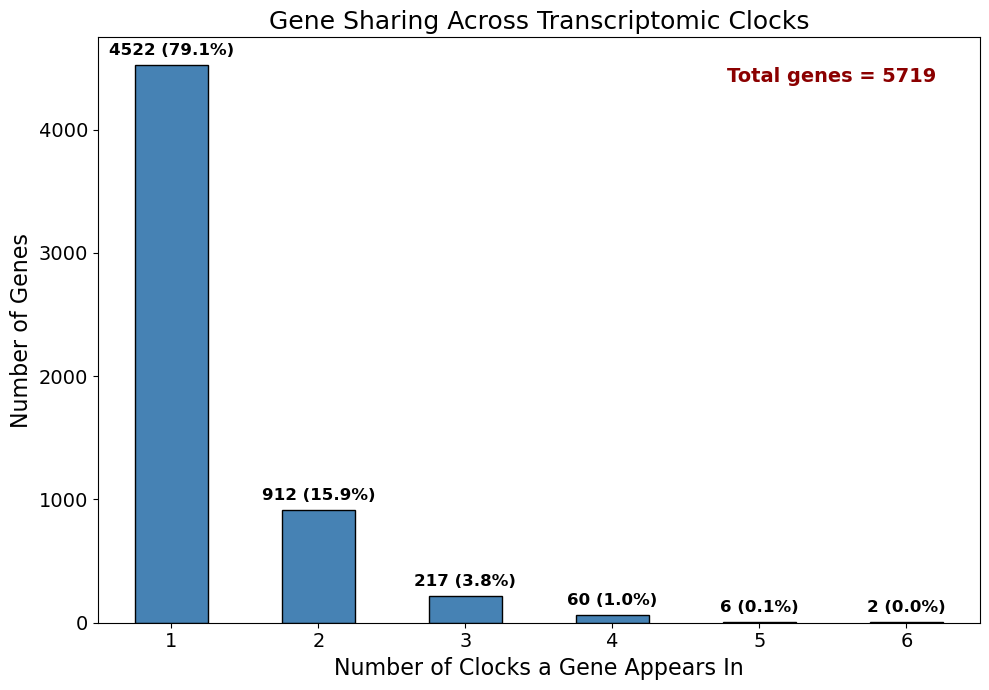

C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\upsetplot\plotting.py:644: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\upsetplot\plotting.py:645: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

<Figure size 800x600 with 0 Axes>

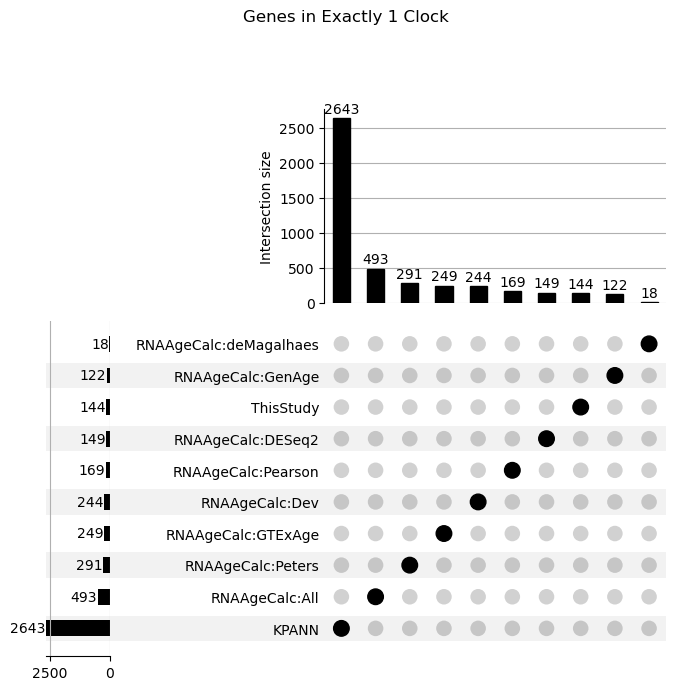

C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\upsetplot\plotting.py:644: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\upsetplot\plotting.py:645: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

<Figure size 1500x1200 with 0 Axes>

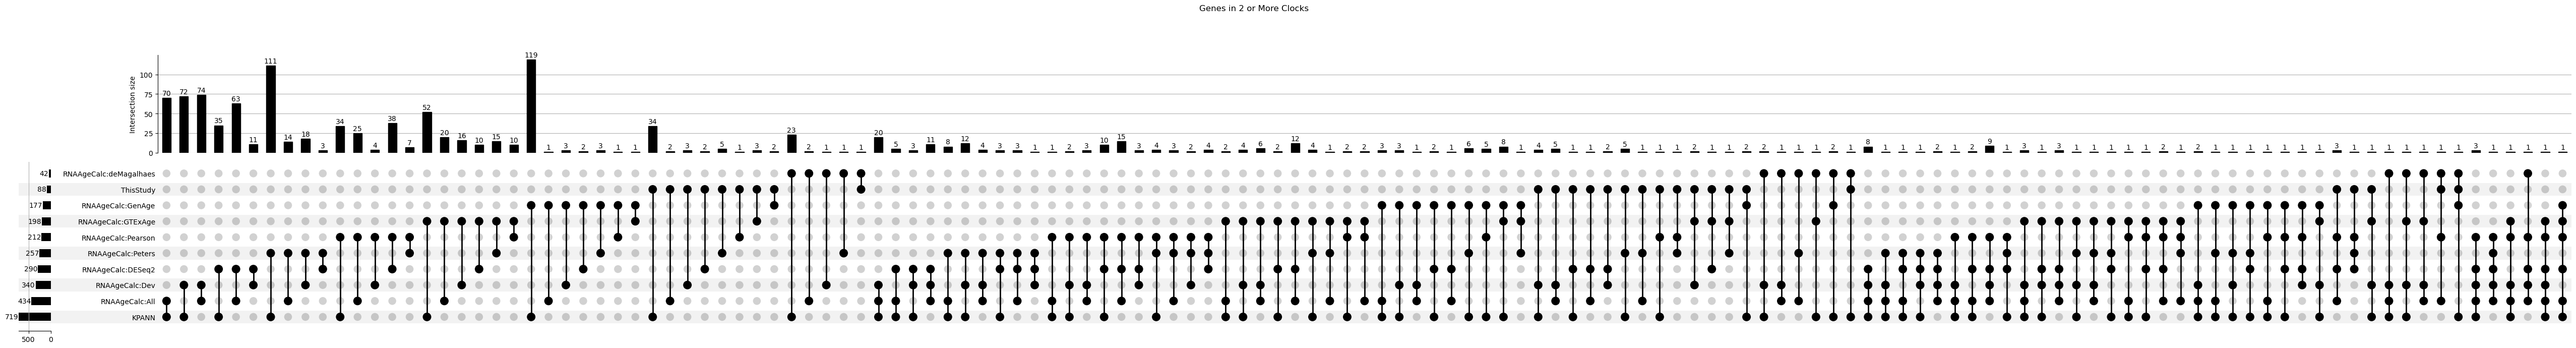

In [20]:
# Work on copy
df_brain_nodes = all_nodes.copy()
# Subset only transcriptome rows
df_transcriptome = df_brain_nodes[df_brain_nodes["Type"].str.contains("transcriptom", case=False, na=False)]

# Pivot to get membership (gene x clock)
df_membership = df_transcriptome.assign(value=1).pivot_table(
    index="Ensembl", 
    columns="Clock", 
    values="value", 
    fill_value=0
)

# Convert 0/1 to boolean (needed by upsetplot)
df_membership = df_membership.astype(bool)

# Convert to UpSet-compatible format
upset_data = from_indicators(df_membership.columns, df_membership)

# Count in how many clocks each gene appears
gene_counts = df_membership.sum(axis=1)

# Tabulate counts (how many genes appear in 1, 2, 3, ... clocks)
distribution = gene_counts.value_counts().sort_index()

# Total number of genes
total_genes = gene_counts.shape[0]

# Make barplot
plt.figure(figsize=(10,7))
ax = distribution.plot(kind="bar", color="steelblue", edgecolor="black")

# Labels
plt.xlabel("Number of Clocks a Gene Appears In", fontsize=16)
plt.ylabel("Number of Genes", fontsize=16)
plt.title("Gene Sharing Across Transcriptomic Clocks", fontsize=18)
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=14)

# Annotate bars with count + percentage
for i, (x, y) in enumerate(distribution.items()):
    percent = (y / total_genes) * 100
    ax.text(i, y + 0.01*total_genes, f"{y} ({percent:.1f}%)", 
            ha="center", va="bottom", fontsize=12, fontweight="bold")

# Add total gene count as text in the corner
plt.text(0.95, 0.95, f"Total genes = {total_genes}", 
         ha="right", va="top", transform=plt.gca().transAxes,
         fontsize=14, fontweight="bold", color="darkred")

plt.tight_layout()

# Save plot (SVG at 600 dpi, per your prefs)
plt.savefig("gene_sharing_transcriptomic_clocks.svg", format="svg", dpi=600)
plt.show()


# Count how many clocks each gene is in
gene_counts = df_membership.sum(axis=1)

# Subset
df_unique = df_membership[gene_counts == 1]   # only 1 clock
df_shared = df_membership[gene_counts >= 2]   # 2 or more clocks

# Convert to UpSet data
upset_unique = from_indicators(df_unique.columns, df_unique)
upset_shared = from_indicators(df_shared.columns, df_shared)

# --- Plot 1: Unique ---
plt.figure(figsize=(8,6))
UpSet(upset_unique, subset_size='count', show_counts=True).plot()
plt.suptitle("Genes in Exactly 1 Clock", y=1.02)
plt.show()

# --- Plot 2: Shared ---
plt.figure(figsize=(15,12))
UpSet(upset_shared, subset_size='count', show_counts=True).plot()
plt.suptitle("Genes in 2 or More Clocks", y=1.02)
plt.show()

In [21]:
# gene_counts is a Series: index = Ensembl, value = number of clocks
gene_membership = gene_counts.reset_index()
gene_membership.columns = ["Ensembl", "NumClocks"]

# Save to CSV
gene_membership.to_csv("gene_membership_transcriptomic_counts.csv", index=False)

# Quick peek
print(gene_membership.head())

           Ensembl  NumClocks
0  ENSG00000000938          1
1  ENSG00000000971          3
2  ENSG00000001036          1
3  ENSG00000001084          2
4  ENSG00000001167          1


In [22]:
# --- Work on a copy ---
df_brain_nodes = all_nodes.copy()

# Split by type
df_transcriptome = df_brain_nodes[df_brain_nodes["Type"].str.contains("transcriptom", case=False, na=False)]
df_epigenetic   = df_brain_nodes[df_brain_nodes["Type"] == "Epigenetic"]

# Pivot each (gene x clock, with membership 0/1)
df_transcriptome_membership = df_transcriptome.assign(value=1).pivot_table(
    index="Ensembl", columns="Clock", values="value", fill_value=0
)

df_epigenetic_membership = df_epigenetic.assign(value=1).pivot_table(
    index="Ensembl", columns="Clock", values="value", fill_value=0
)

# Count how many clocks each gene is in
gene_counts_transcriptome = df_transcriptome_membership.sum(axis=1)
gene_counts_epigenetic    = df_epigenetic_membership.sum(axis=1)

# Put into DataFrames
transcriptome_summary = gene_counts_transcriptome.reset_index()
transcriptome_summary.columns = ["Ensembl", "NumTranscriptomeClocks"]

epigenetic_summary = gene_counts_epigenetic.reset_index()
epigenetic_summary.columns = ["Ensembl", "NumEpigeneticClocks"]

# Merge both summaries (outer join to capture genes from either set)
membership_summary = pd.merge(
    transcriptome_summary, epigenetic_summary, on="Ensembl", how="outer"
).fillna(0)

# Convert counts to integers
membership_summary["NumTranscriptomeClocks"] = membership_summary["NumTranscriptomeClocks"].astype(int)
membership_summary["NumEpigeneticClocks"] = membership_summary["NumEpigeneticClocks"].astype(int)

# Save to CSV
membership_summary.to_csv("gene_membership_transcriptome_epigenetic.csv", index=False)

print(membership_summary.head())

           Ensembl  NumTranscriptomeClocks  NumEpigeneticClocks
0  ENSG00000000938                       1                    0
1  ENSG00000000971                       3                    0
2  ENSG00000001036                       1                    0
3  ENSG00000001084                       2                    0
4  ENSG00000001167                       1                    0


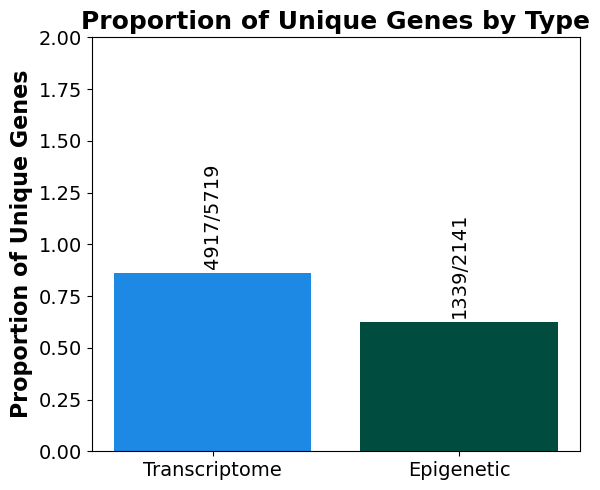

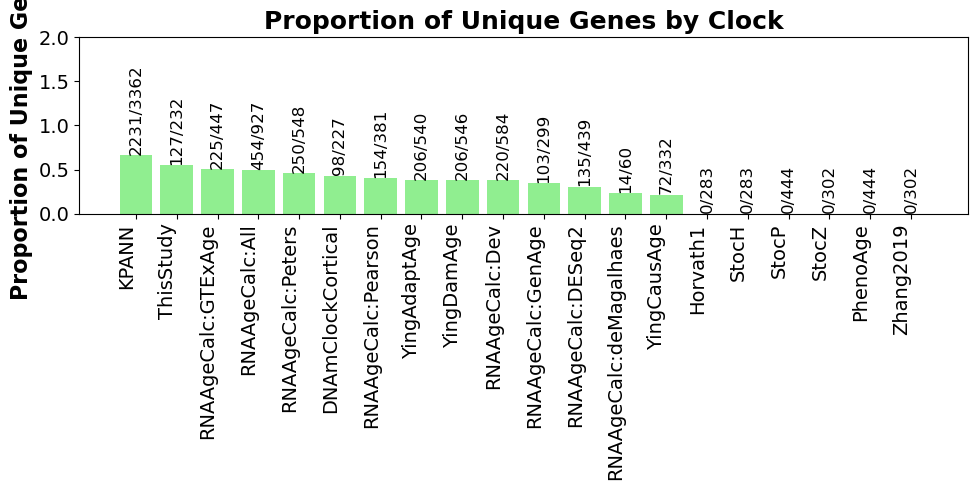

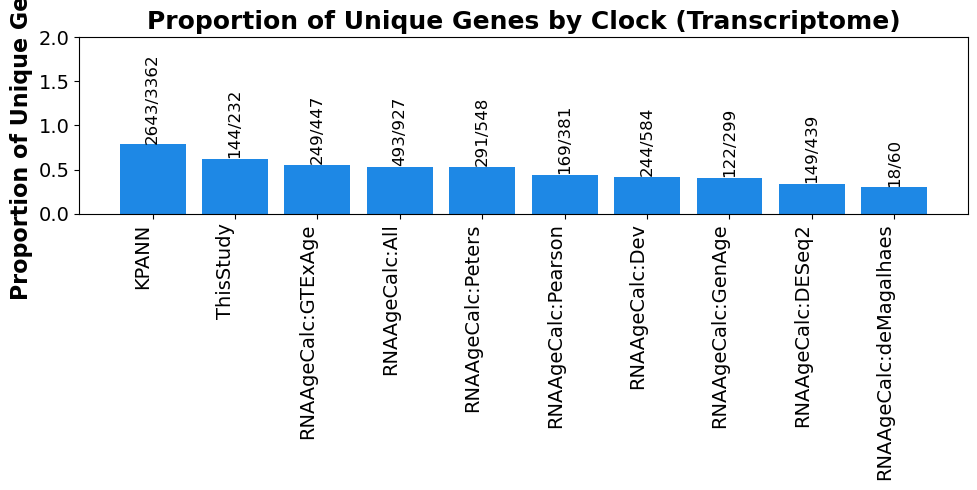

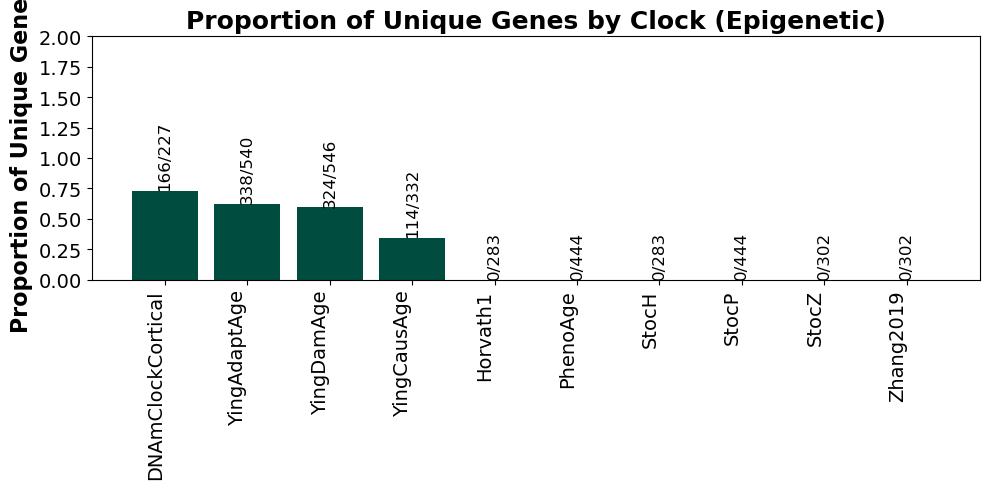

In [25]:
# Work on copy
df = all_nodes.copy()
df = df.drop_duplicates(subset=["Ensembl", "Clock", "Type"])
#df = df.drop_duplicates(subset=["Ensembl"])

# -------------------------------
# Proportion of unique genes by Type
# -------------------------------
# total genes per type
total_by_type = df.groupby("Type")["Ensembl"].nunique()

# sets of genes by type
trans_genes = set(df[df["Type"]=="Transcriptome"]["Ensembl"])
epi_genes   = set(df[df["Type"]=="Epigenetic"]["Ensembl"])

# unique sets
unique_trans = trans_genes - epi_genes
unique_epi   = epi_genes - trans_genes

unique_by_type = pd.Series({
    "Transcriptome": len(unique_trans),
    "Epigenetic": len(unique_epi)
})

# proportions dataframe with counts
prop_by_type = pd.DataFrame({
    "Type": unique_by_type.index,
    "UniqueCount": unique_by_type.values,
    "TotalCount": [total_by_type[t] for t in unique_by_type.index],
})
prop_by_type["Proportion"] = prop_by_type["UniqueCount"] / prop_by_type["TotalCount"]

# sort
prop_by_type = prop_by_type.sort_values("Proportion", ascending=False)

# color mapping
type_colors = {"Transcriptome": "#1E88E5", "Epigenetic": "#004D40"}

# plot
plt.figure(figsize=(6,5))
bars = plt.bar(
    prop_by_type["Type"], 
    prop_by_type["Proportion"], 
    color=[type_colors[t] for t in prop_by_type["Type"]],
    edgecolor=None
)

# add rotated labels
for bar, (unique, total) in zip(bars, zip(prop_by_type["UniqueCount"], prop_by_type["TotalCount"])):
    height = bar.get_height()
    label = f"{unique}/{total}"
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + 0.02, 
        label, 
        ha="center", va="bottom", 
        rotation=90, fontsize=14
    )

plt.ylabel("Proportion of Unique Genes", fontsize=16, fontweight="bold")
plt.title("Proportion of Unique Genes by Type", fontsize=18, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0,2.0)
plt.tight_layout()
plt.savefig("00Fig7a-08282025.pdf", dpi=600, bbox_inches="tight")
plt.show()


# -------------------------------
# Proportion of unique genes by Clock
# -------------------------------
prop_by_clock = []
for clock, sub in df.groupby("Clock"):
    genes = set(sub["Ensembl"])
    other_genes = set(df[df["Clock"] != clock]["Ensembl"])
    unique_genes = genes - other_genes
    total = len(genes)
    unique = len(unique_genes)
    prop = unique / total if total > 0 else 0
    prop_by_clock.append([clock, prop, unique, total])

prop_by_clock = pd.DataFrame(
    prop_by_clock, 
    columns=["Clock", "Proportion", "UniqueCount", "TotalCount"]
).sort_values("Proportion", ascending=False)

# plot
plt.figure(figsize=(10,5))
bars = plt.bar(
    prop_by_clock["Clock"], 
    prop_by_clock["Proportion"], 
    color="lightgreen", edgecolor=None
)

# add rotated labels
for bar, (unique, total) in zip(bars, zip(prop_by_clock["UniqueCount"], prop_by_clock["TotalCount"])):
    height = bar.get_height()
    label = f"{unique}/{total}"
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + 0.005, 
        label, 
        ha="center", va="bottom", 
        rotation=90, fontsize=12
    )

plt.ylabel("Proportion of Unique Genes", fontsize=16, fontweight="bold")
plt.title("Proportion of Unique Genes by Clock", fontsize=18, fontweight="bold")
plt.xticks(rotation=90, ha="right", fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0,2.0)   # cap at 0.5
plt.tight_layout()
plt.savefig("00Fig7b-08282025.pdf", dpi=600, bbox_inches="tight")
plt.show()


# -------------------------------
# Proportion of unique genes by Clock, split by Type
# -------------------------------
for typ in ["Transcriptome", "Epigenetic"]:
    sub_df = df[df["Type"]==typ].copy()
    
    prop_by_clock = []
    for clock, group in sub_df.groupby("Clock"):
        genes = set(group["Ensembl"])
        other_genes = set(sub_df[sub_df["Clock"] != clock]["Ensembl"])
        unique_genes = genes - other_genes
        total = len(genes)
        unique = len(unique_genes)
        prop = unique / total if total > 0 else 0
        prop_by_clock.append([clock, prop, unique, total])
    
    prop_by_clock = pd.DataFrame(
        prop_by_clock, 
        columns=["Clock", "Proportion", "UniqueCount", "TotalCount"]
    ).sort_values("Proportion", ascending=False)
    
    # plot
    plt.figure(figsize=(10,5))
    bars = plt.bar(
        prop_by_clock["Clock"], 
        prop_by_clock["Proportion"], 
        color="#1E88E5" if typ=="Transcriptome" else "#004D40", 
        edgecolor=None
    )
    
    # annotate with "unique/total"
    for bar, (unique, total) in zip(bars, zip(prop_by_clock["UniqueCount"], prop_by_clock["TotalCount"])):
        height = bar.get_height()
        label = f"{unique}/{total}"
        plt.text(
            bar.get_x() + bar.get_width()/2, 
            height + 0.005, 
            label, 
            ha="center", va="bottom", 
            rotation=90, fontsize=12
        )
    
    plt.ylabel("Proportion of Unique Genes", fontsize=16, fontweight="bold")
    plt.title(f"Proportion of Unique Genes by Clock ({typ})", fontsize=18, fontweight="bold")
    plt.xticks(rotation=90, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    
    if typ=="Epigenetic":
        plt.ylim(0,2.0)
    else:
        plt.ylim(0,2.0)
    
    plt.tight_layout()
    plt.savefig(f"00Fig7b-{typ}-08282025.pdf", dpi=600, bbox_inches="tight")
    plt.show()

In [10]:
# -------------------------
# Save as CSV
# -------------------------
all_nodes.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/03merged_genes-08212025.csv", index=False)

In [11]:
# -------------------------
# Build bipartite graph (all genes)
# -------------------------
G = nx.Graph()
clock_nodes = set()
gene_nodes = set()

for _, row in all_nodes.iterrows():
    clock = row['Clock']
    gene = row['Ensembl']
    node_type = row['Type']

    # Add nodes
    G.add_node(clock, bipartite="clock", type=node_type)
    G.add_node(gene, bipartite="gene", type="gene")

    clock_nodes.add(clock)
    gene_nodes.add(gene)

    # Add edge
    G.add_edge(clock, gene)

# Convert to lists if needed
clock_nodes = list(clock_nodes)
gene_nodes = list(gene_nodes)

# -------------------------
# Louvain clustering (topology only)
# -------------------------
partition = community_louvain.best_partition(G, random_state=42)
nx.set_node_attributes(G, partition, "cluster")

# Generate colors for clusters
clusters = set(partition.values())
palette = sns.color_palette("tab20", len(clusters))
cluster_colors = {c: palette[i] for i, c in enumerate(clusters)}

Genes with >5 connections: 37
['ENSG00000168899', 'ENSG00000147889', 'ENSG00000174080', 'ENSG00000158321', 'ENSG00000166426', 'ENSG00000127990', 'ENSG00000163935', 'ENSG00000118495', 'ENSG00000134716', 'ENSG00000080815', 'ENSG00000129993', 'ENSG00000141556', 'ENSG00000179761', 'ENSG00000121691', 'ENSG00000079689', 'ENSG00000127528', 'ENSG00000111641', 'ENSG00000087076', 'ENSG00000088387', 'ENSG00000124762', 'ENSG00000120217', 'ENSG00000100097', 'ENSG00000115317', 'ENSG00000106624', 'ENSG00000099377', 'ENSG00000107551', 'ENSG00000157214', 'ENSG00000104142', 'ENSG00000168056', 'ENSG00000128564', 'ENSG00000266265', 'ENSG00000100307', 'ENSG00000186197', 'ENSG00000071082', 'ENSG00000114650', 'ENSG00000133704', 'ENSG00000136425']


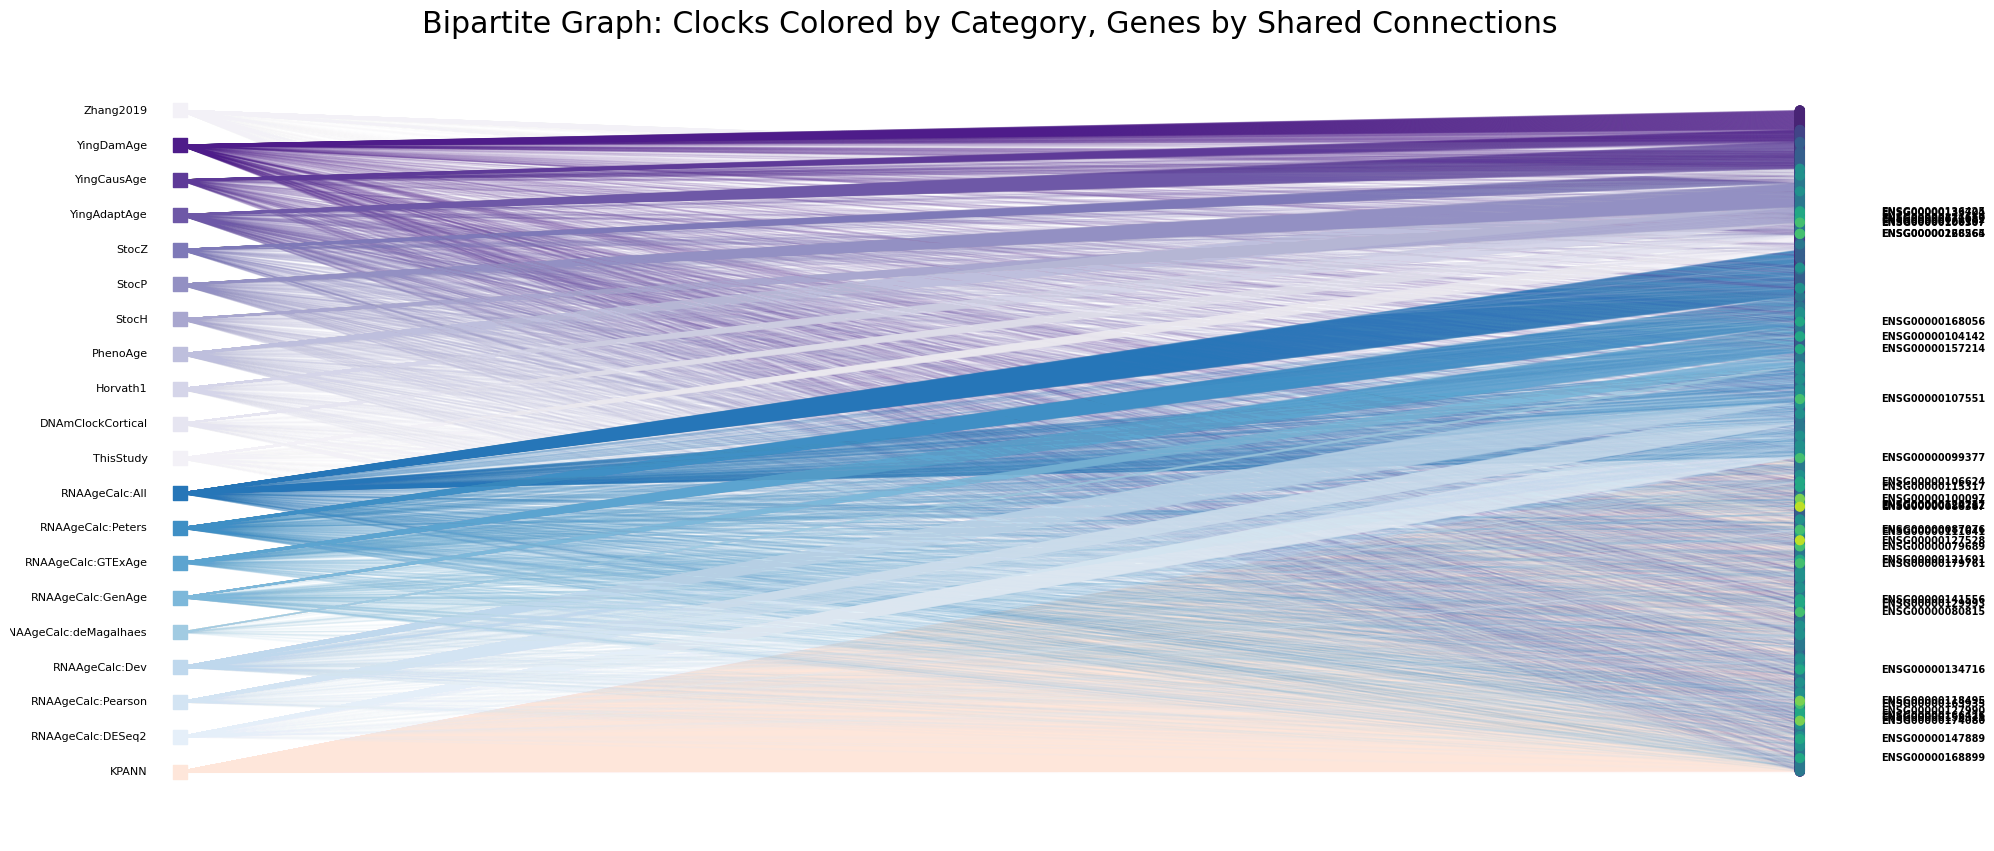

In [17]:
# ----------------------------
# Assume G is already built (no filter on gene connections)
# ----------------------------
clock_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"]=="clock"]
gene_nodes  = [n for n, d in G.nodes(data=True) if d["bipartite"]=="gene"]

# ----------------------------
# Clock category palettes
# ----------------------------
clock_category = {}
for n, d in G.nodes(data=True):
    if d["bipartite"]=="clock":
        if "RNAAgeCalc" in n:
            clock_category[n] = "RNAAgeCalc"
        elif "Epigenetic" in n:
            clock_category[n] = "Epigenetic"
        elif "KPANN" in n:
            clock_category[n] = "KPANN"
        else:
            clock_category[n] = "ThisStudy"

palette_dict = {
    "RNAAgeCalc": sns.color_palette("Blues", 10),
    "Epigenetic": sns.color_palette("Greens", 10),
    "KPANN": sns.color_palette("Reds", 10),
    "ThisStudy": sns.color_palette("Purples", 10)
}

clock_colors = {}
for cat in set(clock_category.values()):
    clocks_in_cat = [c for c in clock_nodes if clock_category[c]==cat]
    pal = palette_dict[cat]
    for i, c in enumerate(clocks_in_cat):
        clock_colors[c] = pal[i % len(pal)]

# ----------------------------
# Gene colors by number of clocks connected
# ----------------------------
gene_degrees = {g: G.degree(g) for g in gene_nodes}
unique_degrees = sorted(list(set(gene_degrees.values())))
gene_palette = sns.color_palette("viridis", len(unique_degrees))
degree_colors = {deg: gene_palette[i] for i, deg in enumerate(unique_degrees)}

# Genes to label (degree > 5)
genes_to_label = [g for g, deg in gene_degrees.items() if deg > 5]
print(f"Genes with >5 connections: {len(genes_to_label)}")
print(genes_to_label)

# ----------------------------
# Layout
# ----------------------------
# Set global style and font scale
sns.set_context("notebook", font_scale=1.8)  # font scale = 1.8
pos = nx.bipartite_layout(G, nodes=clock_nodes, align="vertical")

plt.figure(figsize=(20, 10))
plt.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.1)

# Draw edges
edges = G.edges()
edge_colors = []
for u, v in edges:
    clock = u if G.nodes[u]["bipartite"]=="clock" else v
    edge_colors.append(clock_colors[clock])
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_colors, alpha=0.1)

# Draw clock nodes
for c in clock_nodes:
    nx.draw_networkx_nodes(G, pos, nodelist=[c],
                           node_color=[clock_colors[c]],
                           node_size=100, node_shape="s")

# Draw gene nodes colored by degree
for deg in unique_degrees:
    genes_in_deg = [g for g in gene_nodes if gene_degrees[g]==deg]
    nx.draw_networkx_nodes(G, pos, nodelist=genes_in_deg,
                           node_color=[degree_colors[deg]]*len(genes_in_deg),
                           node_size=40, node_shape="o")

# ----------------------------
# Label genes with >10 connections (shifted for visibility)
# ----------------------------
for g in genes_to_label:
    plt.text(pos[g][0]+0.05, pos[g][1], g,
             fontsize=7, verticalalignment="center", fontweight="bold")

# ----------------------------
# Label clock nodes
# ----------------------------
pos_clock_labels = {c: (pos[c][0] - 0.02, pos[c][1]) for c in clock_nodes}
nx.draw_networkx_labels(
    G, pos_clock_labels, labels={c: c for c in clock_nodes},
    font_size=8, font_color="black", horizontalalignment="right"
)

plt.axis("off")
plt.title("Bipartite Graph: Clocks Colored by Category, Genes by Shared Connections")
plt.show()

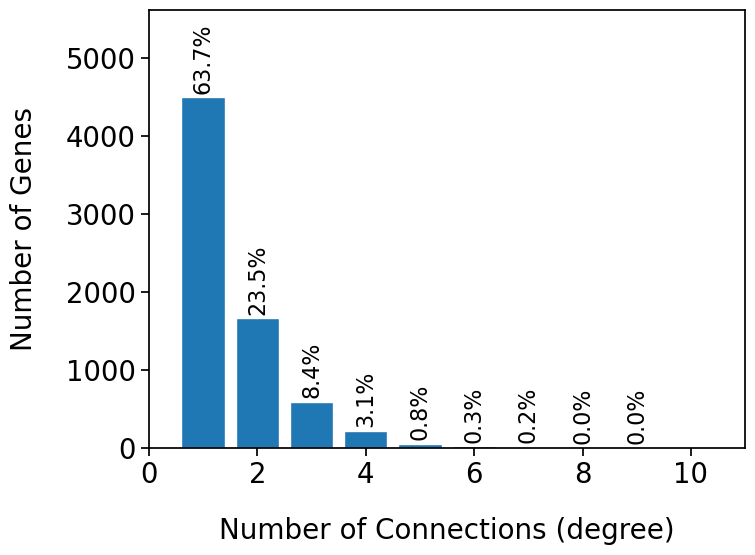

In [15]:
# Extract gene nodes
gene_nodes = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'gene']
# Extract degrees for gene nodes
gene_degree_values = [G.degree(g) for g in gene_nodes]
# Count how many genes have each degree
degree_counts = Counter(gene_degree_values)

# Total number of genes
total_genes = sum(degree_counts.values())

# Plot histogram
plt.figure(figsize=(8, 6))
sns.set_context("notebook", font_scale=1.8)
bars = plt.bar(degree_counts.keys(), degree_counts.values(), edgecolor="white")

# Add percentage annotations on top
for bar, count in zip(bars, degree_counts.values()):
    percentage = (count / total_genes) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,   # offset above bar
        f"{percentage:.1f}%",
        ha="center", va="bottom", fontsize=16,
        rotation=90
    )

plt.xlabel("Number of Connections (degree)", fontsize=20, labelpad=20)
plt.ylabel("Number of Genes", fontsize=20, labelpad=20)
#plt.title("Number of Genes per Degree", fontsize=14)
plt.ylim(0, max(degree_counts.values()) * 1.25)  # adjust y-limit for labels
plt.xlim(0, 11)
plt.tight_layout()
plt.savefig(f"00Fig7d-08282025.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [16]:
# -------------------------
# Save gene connections
# -------------------------
# Extract gene nodes
gene_nodes = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'gene']

# Compute degrees
gene_degrees = {g: G.degree(g) for g in gene_nodes}

# Save as CSV
df_gene_degrees = pd.DataFrame(list(gene_degrees.items()), columns=["Gene", "NumConnections"])
df_gene_degrees.to_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/03gene_connections-08212025.csv",
    index=False
)